# Section 4: Semantic Segmentation with U-Net on Oxford-IIIT Pet Dataset

We implement a U-Net from scratch for **three-class semantic segmentation** (class 0: pet, class 1: border, class 2: background) using the Oxford-IIIT Pet dataset.

The implementation follows the original U-Net architecture:
- Encoder with double-conv blocks and max pooling
- A decoder with upsampling or transposed convolutions
- Skip connections between corresponding encoder and decoder layers
- Final 1×1 convolution to produce 3-class logits

We train two versions:
1. Full U-Net **with** skip connections
2. Ablated U-Net **without** skip connections (to show their importance)

Evaluation uses pixel accuracy and mean Intersection over Union (mIoU).

In [ ]:
# Imports

import torch
torch.manual_seed(42)
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.datasets import OxfordIIITPet
from torch.utils.data import DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### (a) Dataset Preparation

- Images resized to 128×128 and normalized with ImageNet stats.
- Masks are resized with **nearest-neighbor** interpolation (required to preserve integer labels).
- Labels are shifted from {1,2,3} → {0,1,2} for PyTorch CrossEntropyLoss (expects classes starting from 0).
- We split the provided `trainval` split into 80% train and 20% validation.
- Test set is used separately.

In [3]:
# Transforms for images
image_transform = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# Custom mask transform (nearest-neighbor + label shift)
def mask_transform(mask):
    # mask is PIL Image with values 1,2,3
    mask = mask.resize((128, 128), resample=Image.NEAREST)
    mask = np.array(mask)
    mask = torch.from_numpy(mask).long() - 1  # → 0=pet, 1=background, 2=border
    return mask

In [ ]:
# Load datasets
full_train_dataset = OxfordIIITPet(
    root='./data',
    split='trainval',
    target_types='segmentation',
    download=True,
    transform=image_transform,
    target_transform=mask_transform
)

test_dataset = OxfordIIITPet(
    root='./data',
    split='test',
    target_types='segmentation',
    download=True,
    transform=image_transform,
    target_transform=mask_transform
)

# Split trainval into train (80%) and val (20%)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 2944, Val: 736, Test: 3669


In [6]:
# DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

### Visualization of 5 Image-Mask Pairs

We display original images alongside their ground-truth segmentation masks to verify correct loading and preprocessing.
Colors: 0 (pet) = green, 1 (border) = red, 2 (background) = blue


=== Visualizing 5 image-mask pairs ===


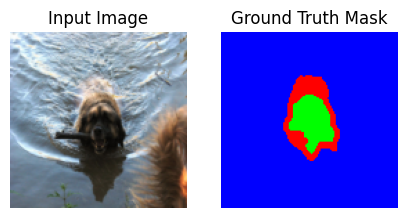

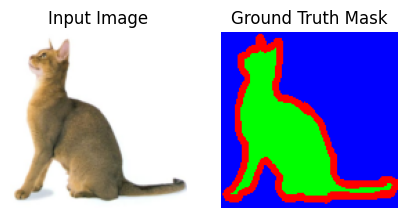

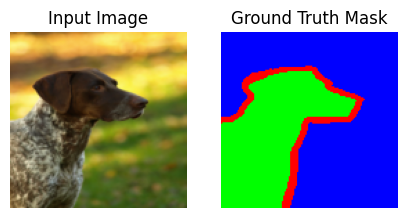

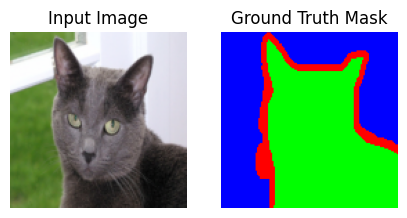

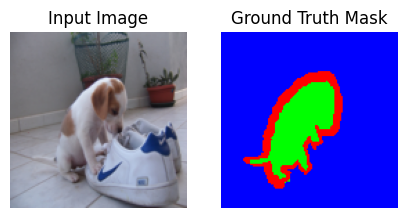

In [7]:
# Visualize 5 image-mask pairs
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return img_tensor * std + mean

def colorize_mask(mask_np):
    # 0=pet (green), 1=background (blue), 2=border (red)
    color = np.zeros((128, 128, 3), dtype=np.uint8)
    color[mask_np == 0] = [0, 255, 0]    # pet
    color[mask_np == 1] = [0, 0, 255]    # background
    color[mask_np == 2] = [255, 0, 0]    # border
    return color

print("\n=== Visualizing 5 image-mask pairs ===")
for i in range(5):
    img, mask = train_dataset[i]
    img_np = denormalize(img).permute(1,2,0).clamp(0,1).numpy()
    mask_color = colorize_mask(mask.numpy())
    
    plt.figure(figsize=(5,5))
    plt.subplot(1,2,1)
    plt.imshow(img_np)
    plt.title("Input Image")
    plt.axis('off')
    
    plt.subplot(1,2,2)
    plt.imshow(mask_color)
    plt.title("Ground Truth Mask")
    plt.axis('off')
    plt.show()

### UNet model from Scratch

Below is the implementation of the UNet model from scratch accoding to the architecture mentioned in the assignment.

In [ ]:
# Defining convolutional block
def conv_block(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        # nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        # nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    )

In [ ]:
# Defining U-Net model
class UNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNet, self).__init__()
        # Encoder
        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # Transpose Convolutions for upsampling
        self.upconv3 = nn.ConvTranspose2d(512, 256,
                                          kernel_size=2, stride=2)
        self.upconv2 = nn.ConvTranspose2d(256, 128,
                                          kernel_size=2, stride=2)
        self.upconv1 = nn.ConvTranspose2d(128, 64,
                                          kernel_size=2, stride=2)
        # Decoder
        self.dec1 = conv_block(512, 256)
        self.dec2 = conv_block(256, 128)
        self.dec3 = conv_block(128, 64)
        # Final output layer
        self.out = nn.Conv2d(64, out_channels, kernel_size=1)
        
    def forward(self, x):
        # Encoder
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))
        x3 = self.enc3(self.pool(x2))
        x4 = self.enc4(self.pool(x3))
        
        # Decoder with skip connections
        x = self.upconv3(x4)
        x = torch.cat([x, x3], dim=1)
        x = self.dec1(x)
        
        x = self.upconv2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.dec2(x)
        
        x = self.upconv1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.dec3(x)
        
        # Final output
        return self.out(x)

### Training, Loss Curves, and Quantitative Evaluation

- Loss: CrossEntropyLoss (standard for multi-class segmentation)
- Optimizer: Adam with lr=1e-3
- We train for 25 epochs
- Metrics: Pixel accuracy and mean IoU (implemented manually)
- Two models trained separately

In [10]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    return running_loss / len(loader)

def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            running_loss += loss.item()
    return running_loss / len(loader)

def evaluate_metrics(model, loader):
    model.eval()
    total_correct = 0
    total_pixels = 0
    class_inter = torch.zeros(3)
    class_union = torch.zeros(3)
    
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            pred = torch.argmax(outputs, dim=1)
            
            total_correct += (pred == masks).sum().item()
            total_pixels += masks.numel()
            
            for cls in range(3):
                inter = ((pred == cls) & (masks == cls)).sum().item()
                union = ((pred == cls) | (masks == cls)).sum().item() + 1e-6
                class_inter[cls] += inter
                class_union[cls] += union
    
    pixel_acc = total_correct / total_pixels
    miou = (class_inter / class_union).mean().item()
    return pixel_acc, miou

# Training function
def train_model(model, num_epochs=30, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss = validate(model, val_loader, criterion)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        print(f"Epoch {epoch+1:2d}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        
    return train_losses, val_losses

In [ ]:
# Training the model with skip connections
model = UNet(in_channels=3, out_channels=3).to(device)
train_losses, val_losses = train_model(model, num_epochs=25, lr=0.001)

Epoch  1/25 | Train Loss: 0.8756 | Val Loss: 0.7177
Epoch  2/25 | Train Loss: 0.7021 | Val Loss: 0.6494
Epoch  3/25 | Train Loss: 0.6340 | Val Loss: 0.6269
Epoch  4/25 | Train Loss: 0.6031 | Val Loss: 0.6167
Epoch  5/25 | Train Loss: 0.5531 | Val Loss: 0.5318
Epoch  6/25 | Train Loss: 0.5002 | Val Loss: 0.4632
Epoch  7/25 | Train Loss: 0.4561 | Val Loss: 0.4280
Epoch  8/25 | Train Loss: 0.4361 | Val Loss: 0.4198
Epoch  9/25 | Train Loss: 0.4155 | Val Loss: 0.4032
Epoch 10/25 | Train Loss: 0.3889 | Val Loss: 0.3796
Epoch 11/25 | Train Loss: 0.3834 | Val Loss: 0.3636
Epoch 12/25 | Train Loss: 0.3680 | Val Loss: 0.3806
Epoch 13/25 | Train Loss: 0.3389 | Val Loss: 0.3552
Epoch 14/25 | Train Loss: 0.3289 | Val Loss: 0.3738
Epoch 15/25 | Train Loss: 0.3165 | Val Loss: 0.3553
Epoch 16/25 | Train Loss: 0.3006 | Val Loss: 0.3366
Epoch 17/25 | Train Loss: 0.2919 | Val Loss: 0.3467
Epoch 18/25 | Train Loss: 0.2856 | Val Loss: 0.3399
Epoch 19/25 | Train Loss: 0.2691 | Val Loss: 0.3387
Epoch 20/25 

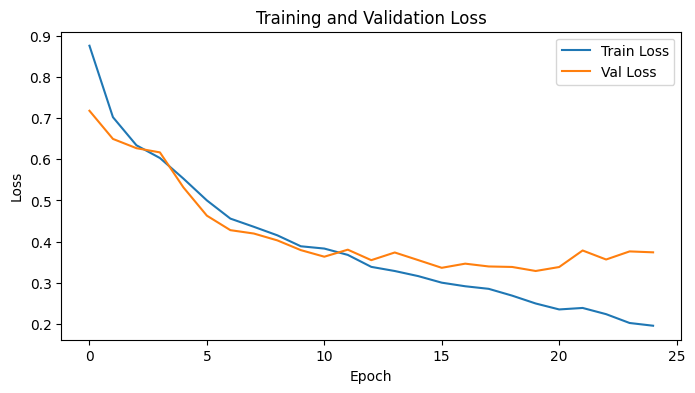

In [14]:
# Plot loss curves
plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.savefig("Unet_losses.png")
plt.show()

In [15]:
# Final test metrics
pixel_acc, miou = evaluate_metrics(model, test_loader)
print(f"Test Pixel Accuracy: {pixel_acc:.4f} | Test mIoU: {miou:.4f}")

Test Pixel Accuracy: 0.8743 | Test mIoU: 0.6916


In [16]:
import pickle

with open('unet_loss_and_acc.pkl', 'wb') as f:
    pickle.dump({
        "train_losses": train_losses,
        "val_losses": val_losses,
        "pixel_acc": pixel_acc,
        "miou": miou
    }, f)

### Model Architecture for UNet without skip connections

Below is the implementation for the UNet without skip connections.

In [ ]:
# Defining U-Net model without skip connections
class UNetNoSkip(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNetNoSkip, self).__init__()

        # Encoder
        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Decoder (no skip connections → no channel doubling)
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec1 = conv_block(256, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(128, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec3 = conv_block(64, 64)

        # Output
        self.out = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))
        x3 = self.enc3(self.pool(x2))
        x4 = self.enc4(self.pool(x3))

        # Decoder
        x = self.upconv3(x4)
        x = self.dec1(x)

        x = self.upconv2(x)
        x = self.dec2(x)

        x = self.upconv1(x)
        x = self.dec3(x)

        return self.out(x)


In [ ]:
# Training the model without skip connections
model_no_skip = UNetNoSkip(in_channels=3, out_channels=3).to(device)
train_losses_no_skip, val_losses_no_skip = train_model(model_no_skip, num_epochs=25, lr=0.001)

Epoch  1/25 | Train Loss: 0.9926 | Val Loss: 0.9491
Epoch  2/25 | Train Loss: 0.8942 | Val Loss: 0.7819
Epoch  3/25 | Train Loss: 0.7674 | Val Loss: 0.7323
Epoch  4/25 | Train Loss: 0.7159 | Val Loss: 0.6821
Epoch  5/25 | Train Loss: 0.6648 | Val Loss: 0.6314
Epoch  6/25 | Train Loss: 0.6120 | Val Loss: 0.6023
Epoch  7/25 | Train Loss: 0.5788 | Val Loss: 0.5574
Epoch  8/25 | Train Loss: 0.5316 | Val Loss: 0.5075
Epoch  9/25 | Train Loss: 0.5020 | Val Loss: 0.4907
Epoch 10/25 | Train Loss: 0.4751 | Val Loss: 0.4604
Epoch 11/25 | Train Loss: 0.4667 | Val Loss: 0.4377
Epoch 12/25 | Train Loss: 0.4340 | Val Loss: 0.4341
Epoch 13/25 | Train Loss: 0.4234 | Val Loss: 0.4163
Epoch 14/25 | Train Loss: 0.4037 | Val Loss: 0.4193
Epoch 15/25 | Train Loss: 0.3933 | Val Loss: 0.3979
Epoch 16/25 | Train Loss: 0.3861 | Val Loss: 0.4093
Epoch 17/25 | Train Loss: 0.3650 | Val Loss: 0.3859
Epoch 18/25 | Train Loss: 0.3604 | Val Loss: 0.3996
Epoch 19/25 | Train Loss: 0.3504 | Val Loss: 0.3720
Epoch 20/25 

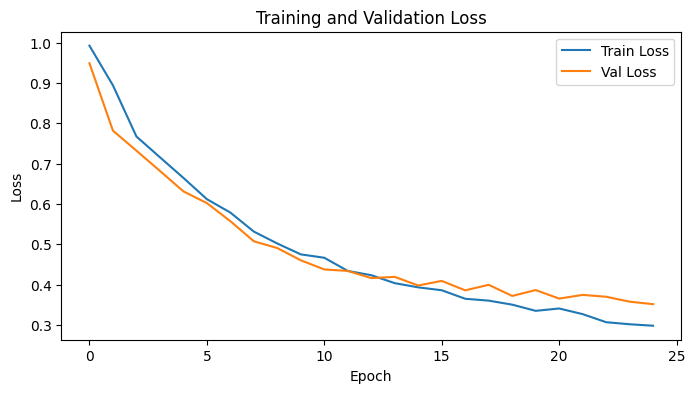

In [22]:
# Plot loss curves
plt.figure(figsize=(8,4))
plt.plot(train_losses_no_skip, label='Train Loss')
plt.plot(val_losses_no_skip, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.savefig("Unet_no_skip_losses.png")
plt.show()

In [20]:
# Final test metrics
pixel_acc_no_skip, miou_no_skip = evaluate_metrics(model_no_skip, test_loader)
print(f"Test Pixel Accuracy: {pixel_acc_no_skip:.4f} | Test mIoU: {miou_no_skip:.4f}")

Test Pixel Accuracy: 0.8634 | Test mIoU: 0.6595


In [21]:
with open('unet_loss_and_acc_no_skip.pkl', 'wb') as f:
    pickle.dump({
        "train_losses": train_losses_no_skip,
        "val_losses": val_losses_no_skip,
        "pixel_acc": pixel_acc_no_skip,
        "miou": miou_no_skip
    }, f)

### Qualitative Segmentation Results

We visualize:
1. Input image
2. Ground-truth segmentation mask
3. Predicted segmentation mask

These examples help assess boundary quality and object completeness.


In [ ]:
# Function to visualize qualitative segmentation results
# This is used to compare the input image, ground-truth mask,
# and the predicted segmentation mask produced by the model.
def visualize_predictions(model, indices, title_prefix=""):
    
    # Set the model to evaluation mode
    # This disables layers such as dropout and batch normalization updates
    model.eval()
    
    print(f"\n=== {title_prefix} ===")
    
    # Iterate over selected sample indices from the test dataset
    for idx in indices:
        
        # Retrieve image and ground-truth mask from the test dataset
        img, gt_mask = test_dataset[idx]
        
        # Add batch dimension and move image tensor to the appropriate device (CPU/GPU)
        img_tensor = img.unsqueeze(0).to(device)
        
        # Disable gradient computation since we are only performing inference
        with torch.no_grad():
            
            # Forward pass through the model to obtain per-pixel class logits
            pred_logits = model(img_tensor)
            
            # Convert logits to class predictions by taking argmax over class dimension
            pred_mask = torch.argmax(pred_logits, dim=1).squeeze(0).cpu().numpy()
        
        # Convert the normalized image tensor back to a displayable NumPy image
        # denormalize() restores original pixel value range
        img_np = denormalize(img).permute(1, 2, 0).clamp(0, 1).numpy()
        
        # Convert ground-truth mask labels to color-coded segmentation map
        gt_color = colorize_mask(gt_mask.numpy())
        
        # Convert predicted mask labels to color-coded segmentation map
        pred_color = colorize_mask(pred_mask)
        
        # Create a figure to display input, ground truth, and prediction side-by-side
        plt.figure(figsize=(15, 5))
        
        # Display input image
        plt.subplot(1, 3, 1)
        plt.imshow(img_np)
        plt.title("Input Image")
        plt.axis('off')
        
        # Display ground-truth segmentation mask
        plt.subplot(1, 3, 2)
        plt.imshow(gt_color)
        plt.title("Ground Truth")
        plt.axis('off')
        
        # Display predicted segmentation mask
        plt.subplot(1, 3, 3)
        plt.imshow(pred_color)
        plt.title("Prediction")
        plt.axis('off')
        
        # Overall title indicating model type or experiment variant
        plt.suptitle(f"{title_prefix} - Sample {idx}")
        plt.show()


In [ ]:
# Function to compute mean Intersection over Union (mIoU) for each test image
def compute_per_image_miou(model, loader):
    
    # Set model to evaluation mode (disables dropout and batch norm updates)
    model.eval()
    
    # Stores mIoU value for each individual image
    per_image_miou = []
    
    # Tracks original index of images in the test dataset
    # This allows mapping low/high mIoU values back to actual samples
    sample_indices = []
    
    # Global index counter across all batches
    idx = 0
    
    # Disable gradient computation since this is evaluation only
    with torch.no_grad():
        
        # Iterate over test data loader in batches
        for images, masks in loader:
            
            # Move images and masks to GPU/CPU
            images, masks = images.to(device), masks.to(device)
            
            # Forward pass to obtain per-pixel class logits
            outputs = model(images)
            
            # Convert logits to predicted class labels for each pixel
            # Output shape: (Batch, Height, Width)
            pred = torch.argmax(outputs, dim=1)
            
            # Determine batch size
            batch_size = images.size(0)
            
            # Compute mIoU separately for each image in the batch
            for b in range(batch_size):
                
                # Predicted segmentation mask for one image
                p = pred[b]      # Shape: (H, W)
                
                # Ground-truth segmentation mask for one image
                m = masks[b]     # Shape: (H, W)
                
                # Initialize tensors to store intersection and union per class
                # We use 3 classes: pet, border, background
                class_inter = torch.zeros(3, device=device)
                class_union = torch.zeros(3, device=device)
                
                # Compute IoU for each class independently
                for cls in range(3):
                    
                    # Intersection: pixels correctly predicted as class cls
                    inter = ((p == cls) & (m == cls)).sum()
                    
                    # Union: pixels belonging to class cls in prediction or ground truth
                    # Small epsilon added to avoid division by zero
                    union = ((p == cls) | (m == cls)).sum() + 1e-6
                    
                    class_inter[cls] = inter
                    class_union[cls] = union
                
                # Compute mean IoU by averaging IoU across all classes
                miou = (class_inter / class_union).mean().cpu().item()
                
                # Store per-image mIoU and corresponding dataset index
                per_image_miou.append(miou)
                sample_indices.append(idx)
                
                # Increment global index
                idx += 1
    
    # Return dataset indices and corresponding per-image mIoU scores
    return sample_indices, per_image_miou


In [26]:
print("\n=== Computing per-image mIoU on test set to find best/worst samples ===")
indices, miou_scores = compute_per_image_miou(model, test_loader)

# Sort by mIoU descending → best first
sorted_pairs = sorted(zip(indices, miou_scores), key=lambda x: x[1], reverse=True)

best_indices  = [idx for idx, _ in sorted_pairs[:5]]
worst_indices = [idx for idx, _ in sorted_pairs[-5:]]

print("Top 5 Best Indices (highest mIoU):", best_indices)
print("Top 5 Worst Indices (lowest mIoU):", worst_indices)


=== Computing per-image mIoU on test set to find best/worst samples ===
Top 5 Best Indices (highest mIoU): [772, 2231, 654, 3012, 1703]
Top 5 Worst Indices (lowest mIoU): [1093, 2302, 1690, 2005, 1858]



=== Good Results (Highest mIoU) ===


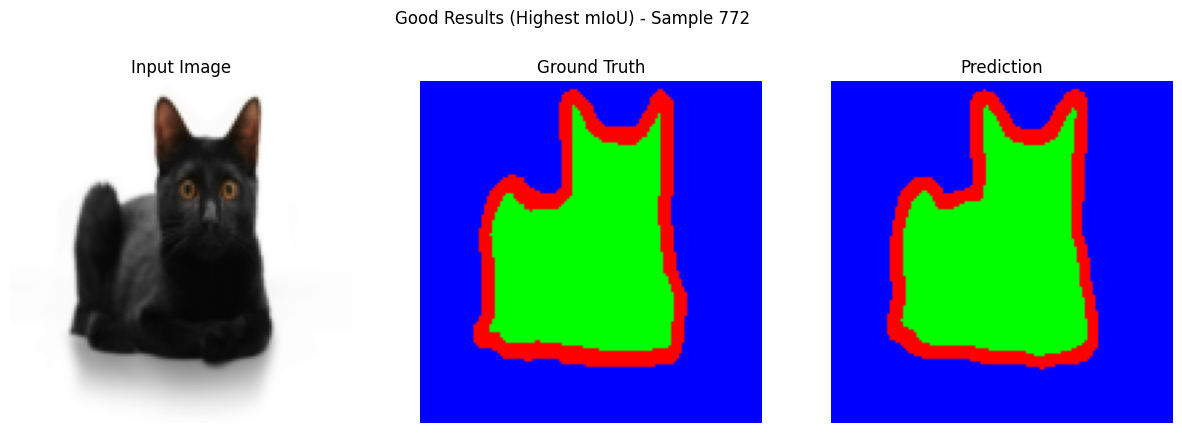

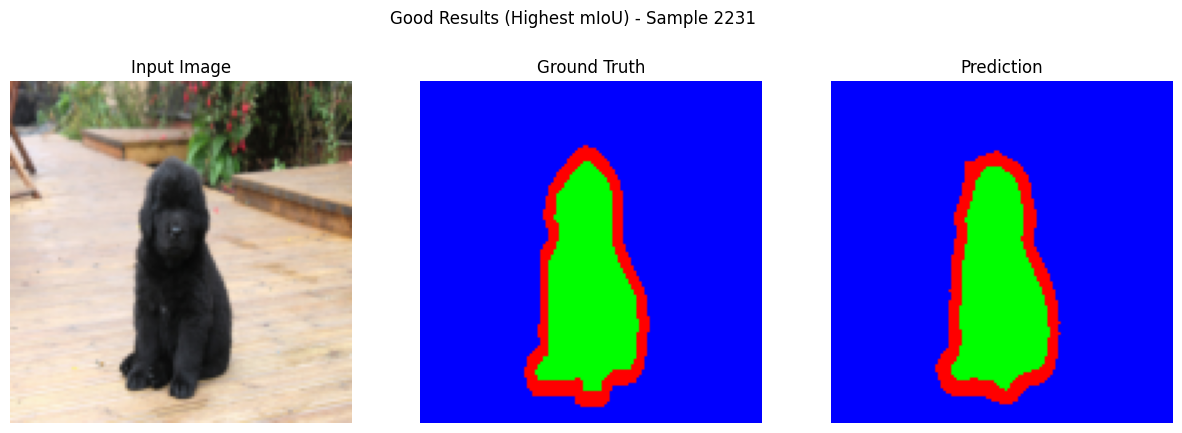

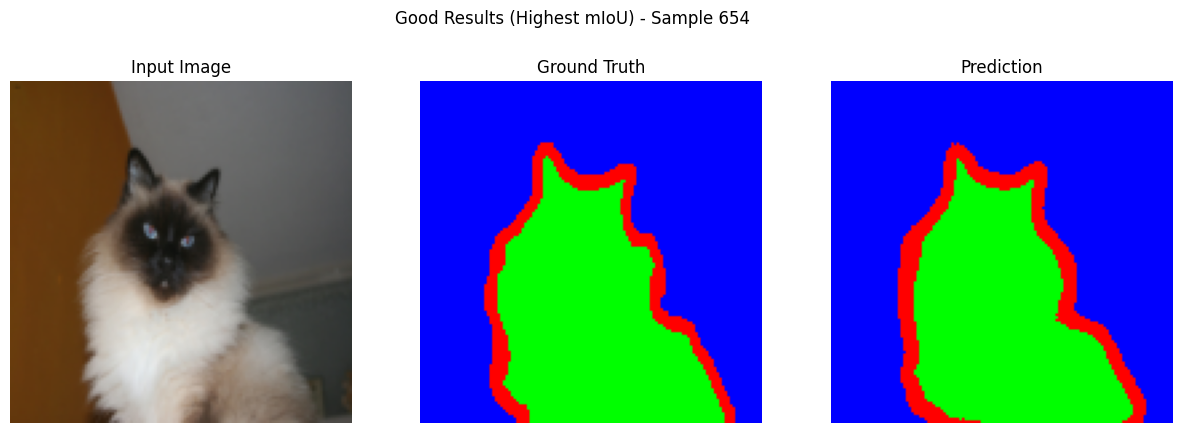

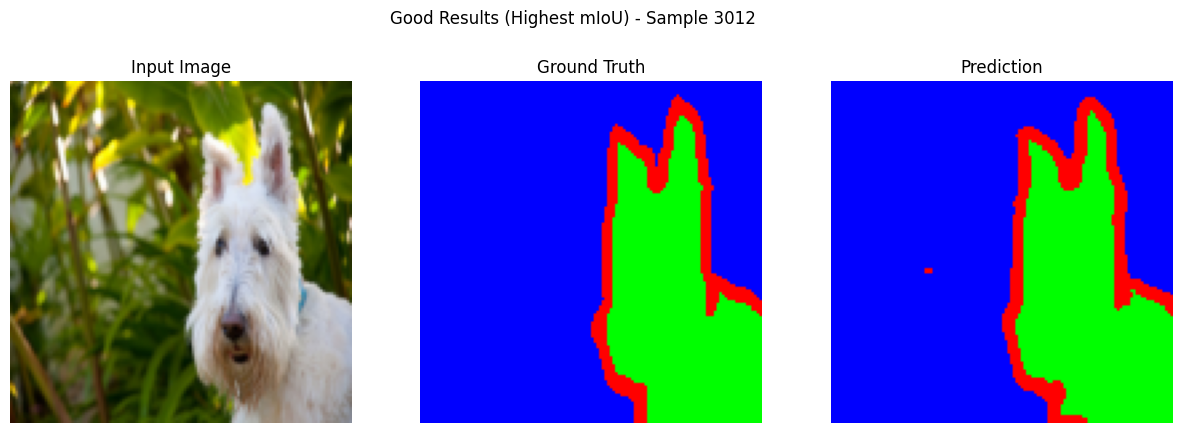

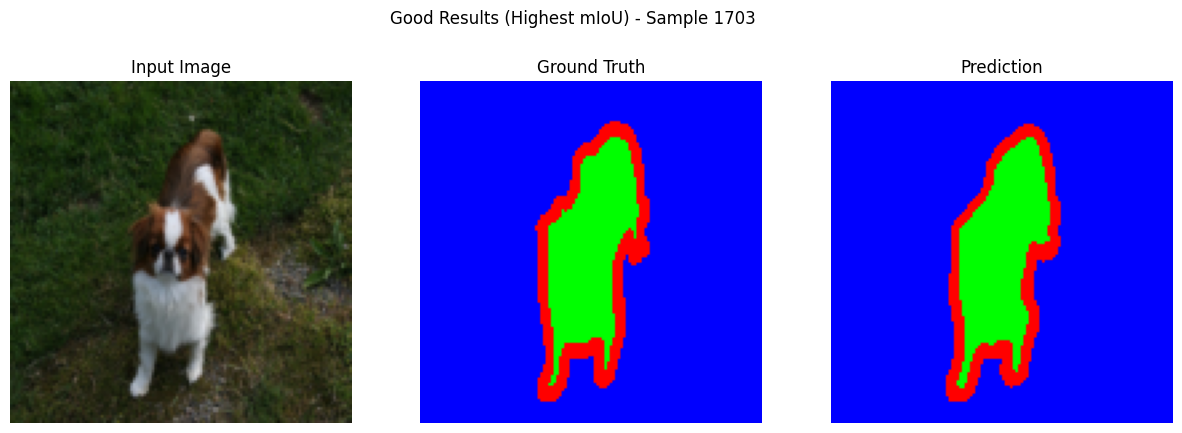

In [ ]:
# Visualize best predictions
visualize_predictions(model, best_indices,  "Good Results (Highest mIoU)")


=== Failure Cases (Lowest mIoU) ===


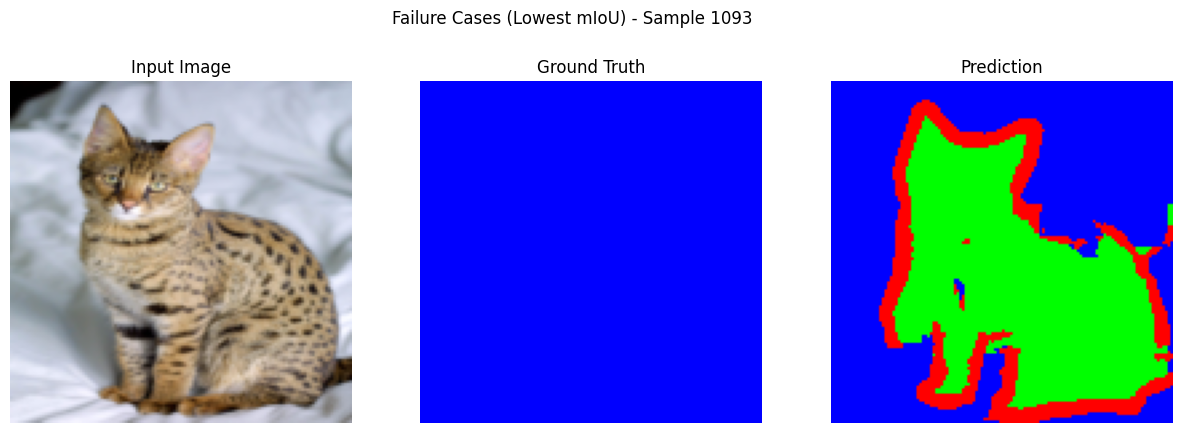

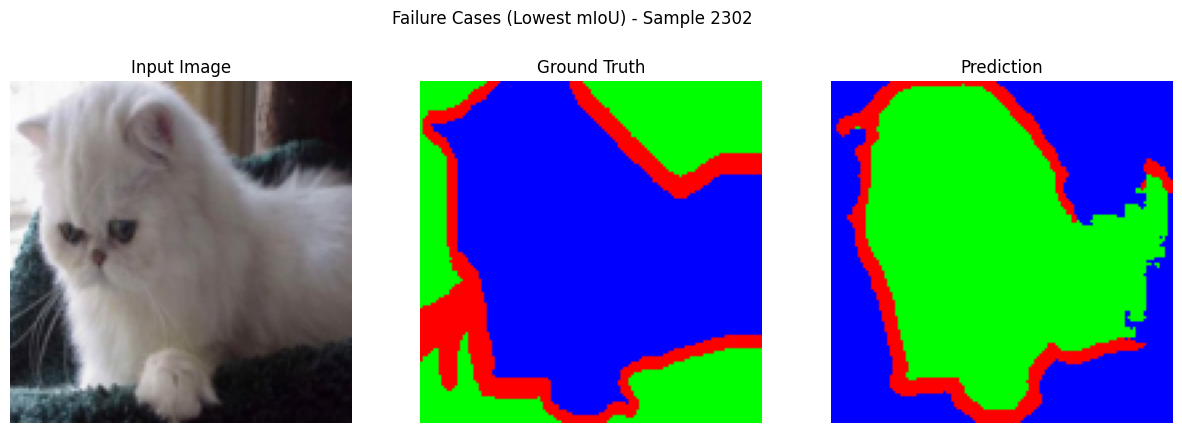

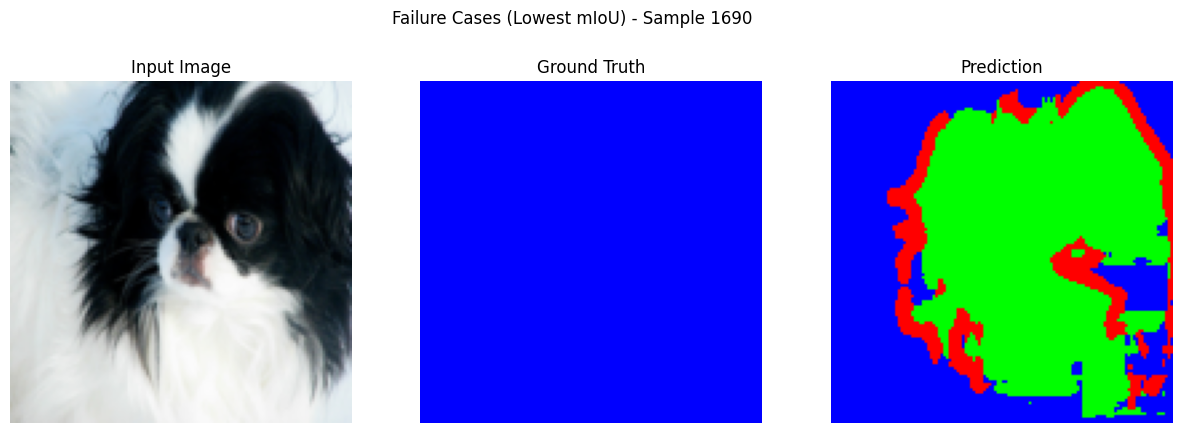

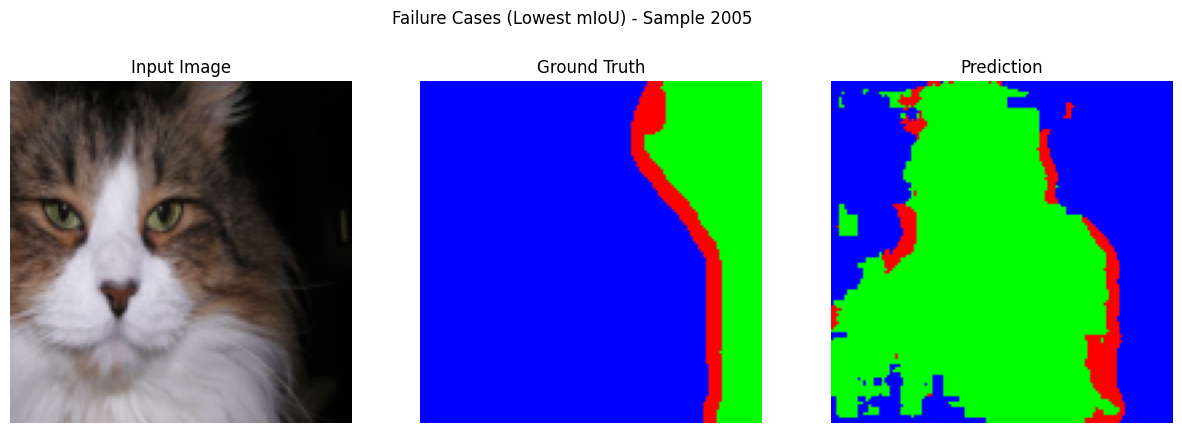

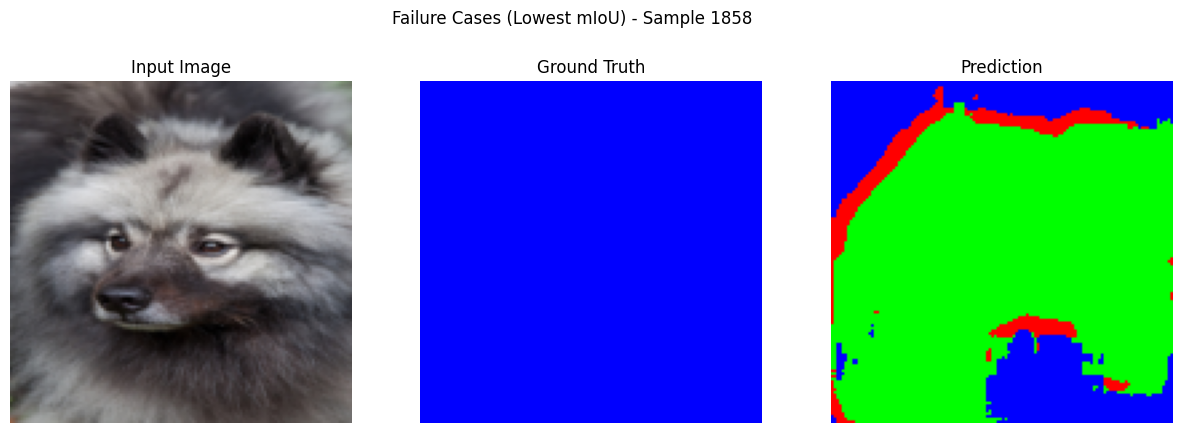

In [28]:
visualize_predictions(model, worst_indices, "Failure Cases (Lowest mIoU)")

### Failure Case Analysis

Failure examples highlight:
- Poor boundary localization
- Small object regions being misclassified
- Confusion between pet borders and background

Such errors often arise due to resolution loss or class imbalance.